In [147]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.decomposition import PCA, KernelPCA
from sklearn.random_projection import SparseRandomProjection
from sklearn.metrics import mean_squared_error
from sklearn.utils.extmath import svd_flip
from scipy.sparse.linalg import svds

Original image shape: (512, 512, 3)
Grayscale image shape: (512, 512)


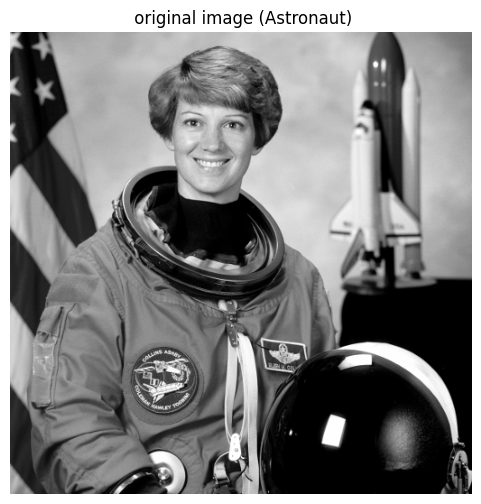

X.shape = (512, 512)


In [148]:
img = data.astronaut()
print("Original image shape:", img.shape)  # (512, 512, 3)

from skimage.color import rgb2gray
img_gray = rgb2gray(img)
print("Grayscale image shape:", img_gray.shape)  # (512, 512)

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
plt.title(' original image (Astronaut)')
plt.axis('off')
plt.show()

# تبدیل به ماتریس X: هر سطر یک پیکسل نیست — ما می‌خواهیم تصویر را به صورت ماتریس m×n نگه داریم
# برای PCA/SVD، معمولاً هر ستون یک "ویژگی" است → پس X.shape = (height, width)
X = img_gray  # shape: (512, 512)
m, n = X.shape
print(f"X.shape = ({m}, {n})")

In [149]:

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.utils.extmath import randomized_svd

from skimage.transform import resize

# KernelPCA برای تصاویر بزرگ بسیار کند است، بنابراین تصویر را کوچک می‌کنیم
#X_kpca = resize(X, (64, 64), anti_aliasing=True)

def reconstruct_and_compute_mse(X, method, k):
    """
    X: image as a matrix (m, n)
    method: 'PCA', 'SVD', 'KernelPCA', 'NMF'
    k: number of components
    """
    if method == 'KernelPCA':
        # downsampled image
        X_small = resize(X, (512, 512), anti_aliasing=True)

        best_mse = np.inf
        best_gamma = None
        for g in [0.0001, 0.001, 0.005, 0.01, 0.015, 0.02, 0.025, 0.035, 0.04, 0.045, 0.05, 0.075, 0.1, 0.125, 0.15, 0.175, 0.2, 0.25, 0.3, 0.5, 0.8, 1]:
            kpca = KernelPCA(n_components=k, kernel='rbf', gamma=g,
                             fit_inverse_transform=True, random_state=42)
            X_transformed = kpca.fit_transform(X_small)
            X_rec = kpca.inverse_transform(X_transformed)
            checkmse = mean_squared_error(X_small, X_rec)
            if checkmse < best_mse:
                best_mse = checkmse
                best_gamma = g
                
        print(f"Best gamma for k={k}: {best_gamma}")
        X_reconstructed = kpca.inverse_transform(X_transformed)
        mse = best_mse
    else:
        m, n = X.shape
        if method == 'PCA':
            pca = PCA(n_components=k, random_state=42)
            X_transformed = pca.fit_transform(X)
            X_reconstructed = pca.inverse_transform(X_transformed)
        elif method == 'SVD':
            U, s, Vt = randomized_svd(X, n_components=k, random_state=42)
            X_reconstructed = U @ np.diag(s) @ Vt
        elif method == 'NMF':
            nmf = NMF(n_components=k, random_state=42, max_iter=200000, init='nndsvda')
            W = nmf.fit_transform(X + 1e-10)
            H = nmf.components_
            X_reconstructed = W @ H
        else:
            raise ValueError("Unknown method!")
        mse = mean_squared_error(X, X_reconstructed)
    
    return X_reconstructed, mse


In [150]:

k_values = [5, 20, 50, 100]

methods = ['PCA', 'SVD', 'KernelPCA', 'NMF']

results = {method: [] for method in methods}

for k in k_values:
    print(f"Processing k = {k}...")
    for method in methods:
        try:
            _, mse = reconstruct_and_compute_mse(X, method, k)
            results[method].append(mse)
            print(f"  {method}: MSE = {mse:.6f}")
        except Exception as e:
            print(f"  {method}: error — {e}")
            results[method].append(np.nan)
    print()

import pandas as pd
results_df = pd.DataFrame(results, index=k_values)
results_df.index.name = 'k'
print("MSE error table:")
results_df.round(6)

Processing k = 5...
  PCA: MSE = 0.021831
  SVD: MSE = 0.024051
Best gamma for k=5: 0.035
  KernelPCA: MSE = 0.030928
  NMF: MSE = 0.025736

Processing k = 20...
  PCA: MSE = 0.005913
  SVD: MSE = 0.006135
Best gamma for k=5: 0.035
  KernelPCA: MSE = 0.030928
  NMF: MSE = 0.025736

Processing k = 20...
  PCA: MSE = 0.005913
  SVD: MSE = 0.006135
Best gamma for k=20: 0.05
  KernelPCA: MSE = 0.017535
Best gamma for k=20: 0.05
  KernelPCA: MSE = 0.017535
  NMF: MSE = 0.007823

Processing k = 50...
  PCA: MSE = 0.001805
  SVD: MSE = 0.001841
  NMF: MSE = 0.007823

Processing k = 50...
  PCA: MSE = 0.001805
  SVD: MSE = 0.001841
Best gamma for k=50: 0.1
  KernelPCA: MSE = 0.013413
Best gamma for k=50: 0.1
  KernelPCA: MSE = 0.013413
  NMF: MSE = 0.002989

Processing k = 100...
  PCA: MSE = 0.000509
  SVD: MSE = 0.000516
  NMF: MSE = 0.002989

Processing k = 100...
  PCA: MSE = 0.000509
  SVD: MSE = 0.000516
Best gamma for k=100: 0.175
  KernelPCA: MSE = 0.012155
Best gamma for k=100: 0.175


,PCA,SVD,KernelPCA,NMF
k,,,,
5,0.021831,0.024051,0.030928,0.025736
20,0.005913,0.006135,0.017535,0.007823
50,0.001805,0.001841,0.013413,0.002989
100,0.000509,0.000516,0.012155,0.001051


Best gamma for k=20: 0.05


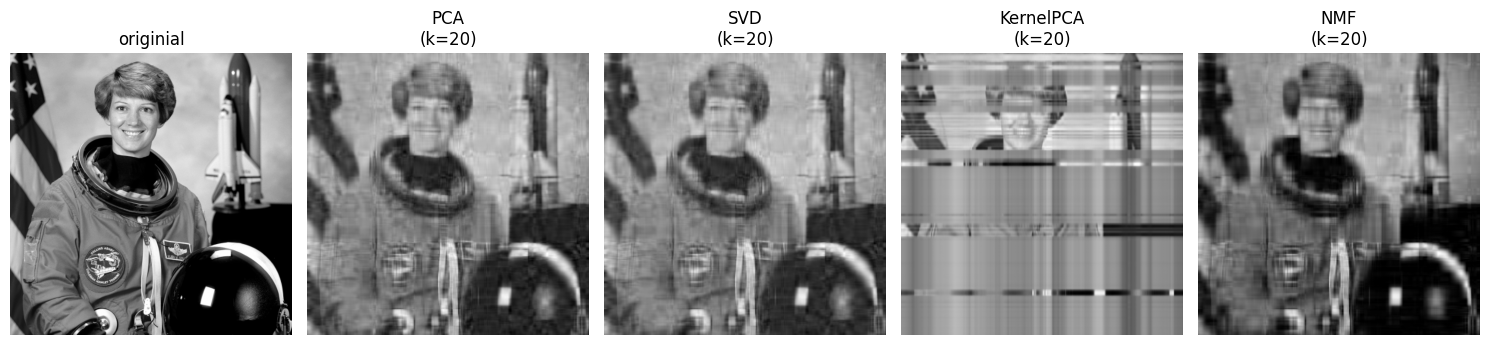

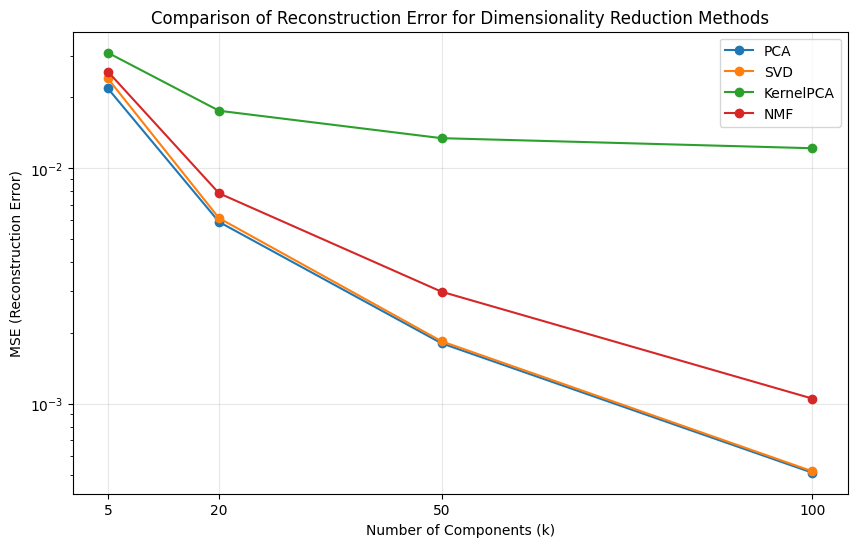


Conclusion:
- PCA and SVD perform very similarly (since SVD underlies PCA).
- NMF is suitable for images because pixel values are non-negative.
- Kernel PCA may work well for small k due to nonlinearity, but it is computationally more expensive.
- As k increases, reconstruction error decreases — but with diminishing returns.
- For this image, PCA/SVD are faster and more efficient.

Best method for each k (lowest MSE):
  k=5: NMF (MSE=0.001051)
  k=20: NMF (MSE=0.001051)
  k=50: NMF (MSE=0.001051)
  k=100: NMF (MSE=0.001051)


In [151]:

k_vis = 20
plt.figure(figsize=(15, 4))

plt.subplot(1, 5, 1)
plt.imshow(X, cmap='gray')
plt.title('originial')
plt.axis('off')

for i, method in enumerate(methods):
    try:
        X_rec, _ = reconstruct_and_compute_mse(X, method, k_vis)
        plt.subplot(1, 5, i+2)
        plt.imshow(X_rec, cmap='gray')
        plt.title(f'{method}\n(k={k_vis})')
        plt.axis('off')
    except:
        plt.subplot(1, 5, i+2)
        plt.text(0.5, 0.5, 'Error', ha='center', va='center')
        plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
for method in methods:
    plt.plot(k_values, results[method], marker='o', label=method)

plt.xlabel('Number of Components (k)')
plt.ylabel('MSE (Reconstruction Error)')
plt.title('Comparison of Reconstruction Error for Dimensionality Reduction Methods')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(k_values)
plt.yscale('log')  
plt.show()

print("\n" + "="*60)
print("Conclusion:")
print("- PCA and SVD perform very similarly (since SVD underlies PCA).")
print("- NMF is suitable for images because pixel values are non-negative.")
print("- Kernel PCA may work well for small k due to nonlinearity, but it is computationally more expensive.")
print("- As k increases, reconstruction error decreases — but with diminishing returns.")
print("- For this image, PCA/SVD are faster and more efficient.")

print("\nBest method for each k (lowest MSE):")
for k in k_values:
    valid_methods = {m: results[m][i] for i, m in enumerate(methods) if not np.isnan(results[m][i])}
    best_method = min(valid_methods, key=valid_methods.get)
    print(f"  k={k}: {best_method} (MSE={valid_methods[best_method]:.6f})")